In [5]:
import pandas as pd
df = pd.read_csv("online_gaming_behavior.csv")
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [6]:
# inspecting the structure

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

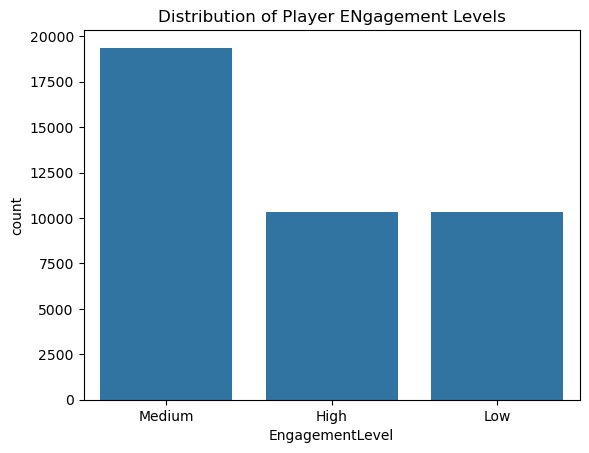

In [7]:
# engagement distribution eval

df['EngagementLevel'].value_counts(normalize=True) * 100

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(data=df, x="EngagementLevel")
plt.title("Distribution of Player ENgagement Levels")
plt.show()

In [8]:
# defining retention proxy, converting engagement to binary rentention logic
# high = retained
# medium/low = at risk

df['retained_flag'] = df['EngagementLevel'].apply(lambda x: 1 if x == "High" else 0)
df['retained_flag'].value_counts(normalize=True)

retained_flag
0    0.741819
1    0.258181
Name: proportion, dtype: float64

In [9]:
## what differentiates highly engaged players?

In [10]:
# A. sessions per week
df.groupby('retained_flag')['SessionsPerWeek'].mean()

retained_flag
0     7.807192
1    14.254547
Name: SessionsPerWeek, dtype: float64

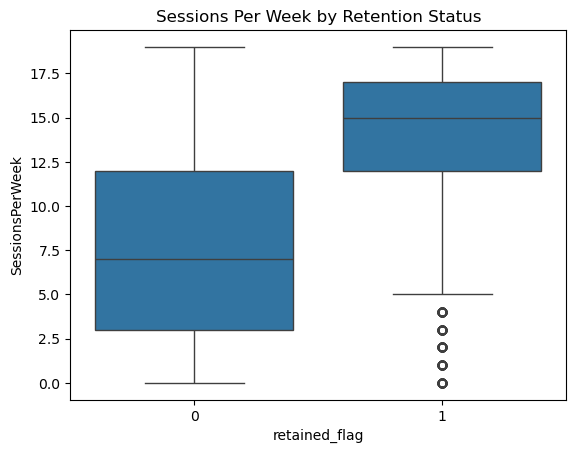

In [11]:
plt.figure()
sns.boxplot(data=df, x='retained_flag', y='SessionsPerWeek')
plt.title("Sessions Per Week by Retention Status")
plt.show()

In [12]:
# B. Avg Session Duration
df.groupby('retained_flag')['AvgSessionDurationMinutes'].mean()

retained_flag
0     81.869789
1    131.921827
Name: AvgSessionDurationMinutes, dtype: float64

In [13]:
# C. Play Time Hours
df.groupby('retained_flag')['PlayTimeHours'].mean()

retained_flag
0    12.008748
1    12.069238
Name: PlayTimeHours, dtype: float64

In [14]:
# D. In-Game Purchases
df.groupby('retained_flag')['InGamePurchases'].mean()

retained_flag
0    0.198902
1    0.206463
Name: InGamePurchases, dtype: float64

In [15]:
# E. Player Progression
df.groupby('retained_flag')[['PlayerLevel', 'AchievementsUnlocked']].mean()

,PlayerLevel,AchievementsUnlocked
retained_flag,,
0,49.249007,24.328271
1,50.823723,25.095975


In [19]:
## identifying high-impact drivers

comparison=df.groupby('retained_flag').mean(numeric_only=True).T
comparison['difference']=comparison[1]-comparison[0]
comparison.sort_values('difference',ascending=False)

retained_flag,0,1,difference
AvgSessionDurationMinutes,81.869789,131.921827,50.052037
PlayerID,29011.521921,29030.803309,19.281388
SessionsPerWeek,7.807192,14.254547,6.447355
PlayerLevel,49.249007,50.823723,1.574716
AchievementsUnlocked,24.328271,25.095975,0.767704
PlayTimeHours,12.008748,12.069238,0.060490
InGamePurchases,0.198902,0.206463,0.007561
Age,32.017745,31.920085,-0.097660


In [20]:
## segment analysis

In [22]:
# segment by game genre
genre_retention = df.groupby('GameGenre')['retained_flag'].mean().sort_values(ascending=False)
genre_retention

GameGenre
Simulation    0.263560
Strategy      0.261732
Sports        0.258822
Action        0.256748
RPG           0.250000
Name: retained_flag, dtype: float64

In [23]:
# segment by Game Difficulty
difficulty_retention = df.groupby('GameDifficulty')['retained_flag'].mean()
difficulty_retention

GameDifficulty
Easy      0.256408
Hard      0.263736
Medium    0.257431
Name: retained_flag, dtype: float64

In [28]:
### Simple Predictive Model

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

df['retained_flag'] = df['retained_flag'].astype(int)

target = 'retained_flag'
feature_cols = [c for c in df.columns if c != target]

X = df[feature_cols]
y = df[target]

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

clf = RandomForestClassifier(
    n_estimators=300,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced_subsample'
)

pipe = Pipeline(steps=[('preprocess', preprocess),
                      ('model', clf)])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)


print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds, digits=3))

[[5940    0]
 [   0 2067]]
              precision    recall  f1-score   support

           0      1.000     1.000     1.000      5940
           1      1.000     1.000     1.000      2067

    accuracy                          1.000      8007
   macro avg      1.000     1.000     1.000      8007
weighted avg      1.000     1.000     1.000      8007

